In [135]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import scipy.constants as constants
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

from wave_optics_propagation_enhanced.classical_numerics import (
    classical_numerics_simulation,
    thin_lens_simulation,
)
from wave_optics_propagation_enhanced.parameters import ExperimentParameters
from wave_optics_propagation_enhanced.result import ExperimentResult

In [136]:
plt.rcParams["text.usetex"] = True
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 14,  # base font size
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "axes.linewidth": 1.2,
    }
)

In [137]:
# EXPERIMENT_ID = "2026-01-08_07-54-21" # reverse, various parameters
# EXPERIMENT_ID = "2026-01-08_08-41-00"  # forward, various parameters

# EXPERIMENT_ID = "2026-01-13_12-46-04"  # reverse, max_delta=0.05
# EXPERIMENT_ID = "2026-01-13_13-20-27"  # reverse, max_delta=0.01

# EXPERIMENT_ID = "2026-01-13_14-02-31"  # reverse, max_delta=0.01, longer z

# EXPERIMENT_ID = "2026-01-16_09-55-12"  # non-fresnel, max_delta=0.1, check waist


############ cluster

# EXPERIMENT_ID = "2026-01-27_10-14-10"  # non-fresnel, max_delta=0.1, waist 23, 7 qubit
# EXPERIMENT_ID = "2026-01-27_11-47-28"  # non-fresnel, max_delta=0.1, waist 23, 6 qubit
# EXPERIMENT_ID = "2026-01-27_12-14-57"  # non-fresnel, max_delta=0.1, waist 20, 6 qubit
# EXPERIMENT_ID = "2026-01-27_12-26-13"  # non-fresnel, max_delta=0.1, waist 25, 6 qubit

# EXPERIMENT_ID = "2026-01-27_12-11-53"  #  non-fresnel, max_delta=0.01, waist 20, 6 qubit

# EXPERIMENT_ID = "2026-01-27_16-06-30"  # non-fresnel, del=0.1, w=23, 6 qubit, non-direct
# EXPERIMENT_ID = "2026-01-27_16-23-42"  # non-fresnel, del=0.1, w=25, 6 qubit, non-direct


# EXPERIMENT_ID = "2026-01-27_16-36-38"  # non-fre, del=0.01, w=23, 6 qubit, direct
# EXPERIMENT_ID = "2026-01-27_16-50-50"  # non-fre, del=0.01, w=23, 6 qubit, non-direct

# EXPERIMENT_ID = "2026-01-29_10-33-38"  # non-fre, del=0.1, w=25, 6 qubit, direct


# EXPERIMENT_ID = "5d25e6d4672541b88adec9c49e7cee22"
# EXPERIMENT_ID = "9c37f675cc31430fa50cd6397166547e"
# EXPERIMENT_ID = "2385107e059c4e7d97494ee394c54dac"
EXPERIMENT_ID = "c137fa26c71f4d64a05047379aa8c74f"


PATH_TO_RESULTS_FOLDER = f".result/{EXPERIMENT_ID}/"

## Pre-processing


In [138]:
params = ExperimentParameters.from_file(path=PATH_TO_RESULTS_FOLDER)
results = ExperimentResult.from_file(path=PATH_TO_RESULTS_FOLDER)
print(params)

vacuum_wavelength=1e-06
beam_FWHM=2.5e-05
focal_length=0.0002
refractive_index=1.25
propagation_after_lens=0.00030000000000000003
transverse_length=0.0001
num_of_steps_after_lens=300
lens_slices=10000
num_qubits=7
max_delta=0.01
lens_reverse_order=True
fresnel_approximation=False
scale_down_phases=True
direct_propagator=False
experiment_datetime=2026-02-05 09:17:46.753265
uuid=c137fa26c71f4d64a05047379aa8c74f


In [139]:
snapshots = results.snapshots


def process_statevector(statevector: np.ndarray) -> np.ndarray:
    return statevector.flatten()


initial_statevector = process_statevector(snapshots[f"step_{0}"])

lens_statevectors = [
    process_statevector(snapshots[f"step_lens_{i}"])
    if f"step_lens_{i}" in snapshots
    else None
    for i in range(params.lens_slices)
]
after_lens_statevectors = [
    process_statevector(snapshots[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in snapshots
    else None
    for i in range(params.num_of_steps_after_lens)
]

In [140]:
for i in range(params.lens_slices):
    if f"step_lens_{i}" not in snapshots:
        print(f"{i}")

for i in range(params.num_of_steps_after_lens):
    if f"step_after_lens_{i + 1}" not in snapshots:
        print(f"{i + 1}")

In [141]:
# classical_numerics_statevectors = []
analytical_thin_lens_after_lens_statevectors = []
analytical_thin_lens_in_lens_statevectors = []


# We first calculate the positions of the principal plane
principal_plane_position = (
    params.lens_thickness
    if params.lens_reverse_order
    else (params.lens_thickness - params.lens_thickness / params.refractive_index)
)

# the case inside the lens. because the principal plane is either inside the lens or at the end of the lens, we have to check this in the loop
for i in range(params.lens_slices):
    z = params.lens_slice_thickness * (i + 1)

    if z < principal_plane_position:
        analytical_result = thin_lens_simulation(
            params,
            propagation_before_lens=z,
            propagation_after_lens=0,
        )
        analytical_thin_lens_in_lens_statevectors.append(analytical_result)

    else:
        analytical_result = thin_lens_simulation(
            params,
            propagation_before_lens=principal_plane_position,
            propagation_after_lens=z - principal_plane_position,
        )
        analytical_thin_lens_in_lens_statevectors.append(analytical_result)

for i in range(params.num_of_steps_after_lens):
    after_lens_distance = params.step_size_after_lens * (i + 1)
    distance_from_principal_plane = (
        params.lens_thickness - principal_plane_position
    ) + after_lens_distance

    analytical_result = thin_lens_simulation(
        params,
        propagation_before_lens=principal_plane_position,
        propagation_after_lens=distance_from_principal_plane,
    )

    analytical_thin_lens_after_lens_statevectors.append(analytical_result)

In [142]:
full_sim_statevectors = lens_statevectors + after_lens_statevectors

full_analytical_thin_lens_statevectors = (
    analytical_thin_lens_in_lens_statevectors
    + analytical_thin_lens_after_lens_statevectors
)

z_axis = [params.lens_slice_thickness * (i + 1) for i in range(params.lens_slices)] + [
    params.lens_thickness + params.step_size_after_lens * (i + 1)
    for i in range(params.num_of_steps_after_lens)
]

## Wavefunction plots


In [143]:
# print("Plotting initial state")
# plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
# plt.suptitle("Initial state")
# plt.show()

# NUM_OF_LENS_SLICES_TO_PLOT = 1
# NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 10

# for i, statevector in enumerate(lens_statevectors):
#     if statevector is None:
#         continue
#     if (
#         results.total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
#         and i % (results.total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
#     ):
#         continue

#     # print(f"Plotting lens slice {i + 1}/{lens_slices}")

#     fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

#     ax1.plot(
#         np.abs(analytical_thin_lens_in_lens_statevectors[i]),
#         "r--",
#         label="thin lens analytical",
#     )

#     plt.suptitle(f"After lens slice {i + 1}/{params.lens_slices}")
#     plt.show()

# for i, statevector in enumerate(after_lens_statevectors):
#     if statevector is None:
#         continue
#     if i % (params.num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
#         continue

#     # print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
#     fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

#     after_lens_distance = params.step_size_after_lens * (i + 1)
#     classical_numerics_result = classical_numerics_simulation(
#         params, propagation_after_lens=after_lens_distance
#     )

#     ax1.plot(
#         np.abs(analytical_thin_lens_after_lens_statevectors[i]),
#         "r--",
#         label="thin lens analytical",
#     )

#     ax1.plot(np.abs(classical_numerics_result), "g--", label="classical numerics")

#     plt.suptitle(f"After free space step {i + 1}/{params.num_of_steps_after_lens}")
#     plt.show()

## Beam waist plots


In [144]:
# map each statevector after lens to its corresponding beam waist

# TODO: verify beam waist calculation
def map_statevector_to_beam_waist(statevector: np.ndarray) -> float:
    intensity = np.abs(statevector) ** 2
    total_intensity = np.sum(intensity)
    x_mean = np.sum(params.x_axis.axis_values * intensity) / total_intensity
    x2_mean = np.sum((params.x_axis.axis_values**2) * intensity) / total_intensity
    variance = x2_mean - x_mean**2
    beam_waist = np.sqrt(variance) * 2  # beam waist approximation
    return beam_waist


analytical_beam_waists = [
    map_statevector_to_beam_waist(statevector)
    for statevector in full_analytical_thin_lens_statevectors
]

# classical_numerics_beam_waists = []

beam_waists = [
    map_statevector_to_beam_waist(statevector)
    for statevector in full_sim_statevectors
    if statevector is not None
]

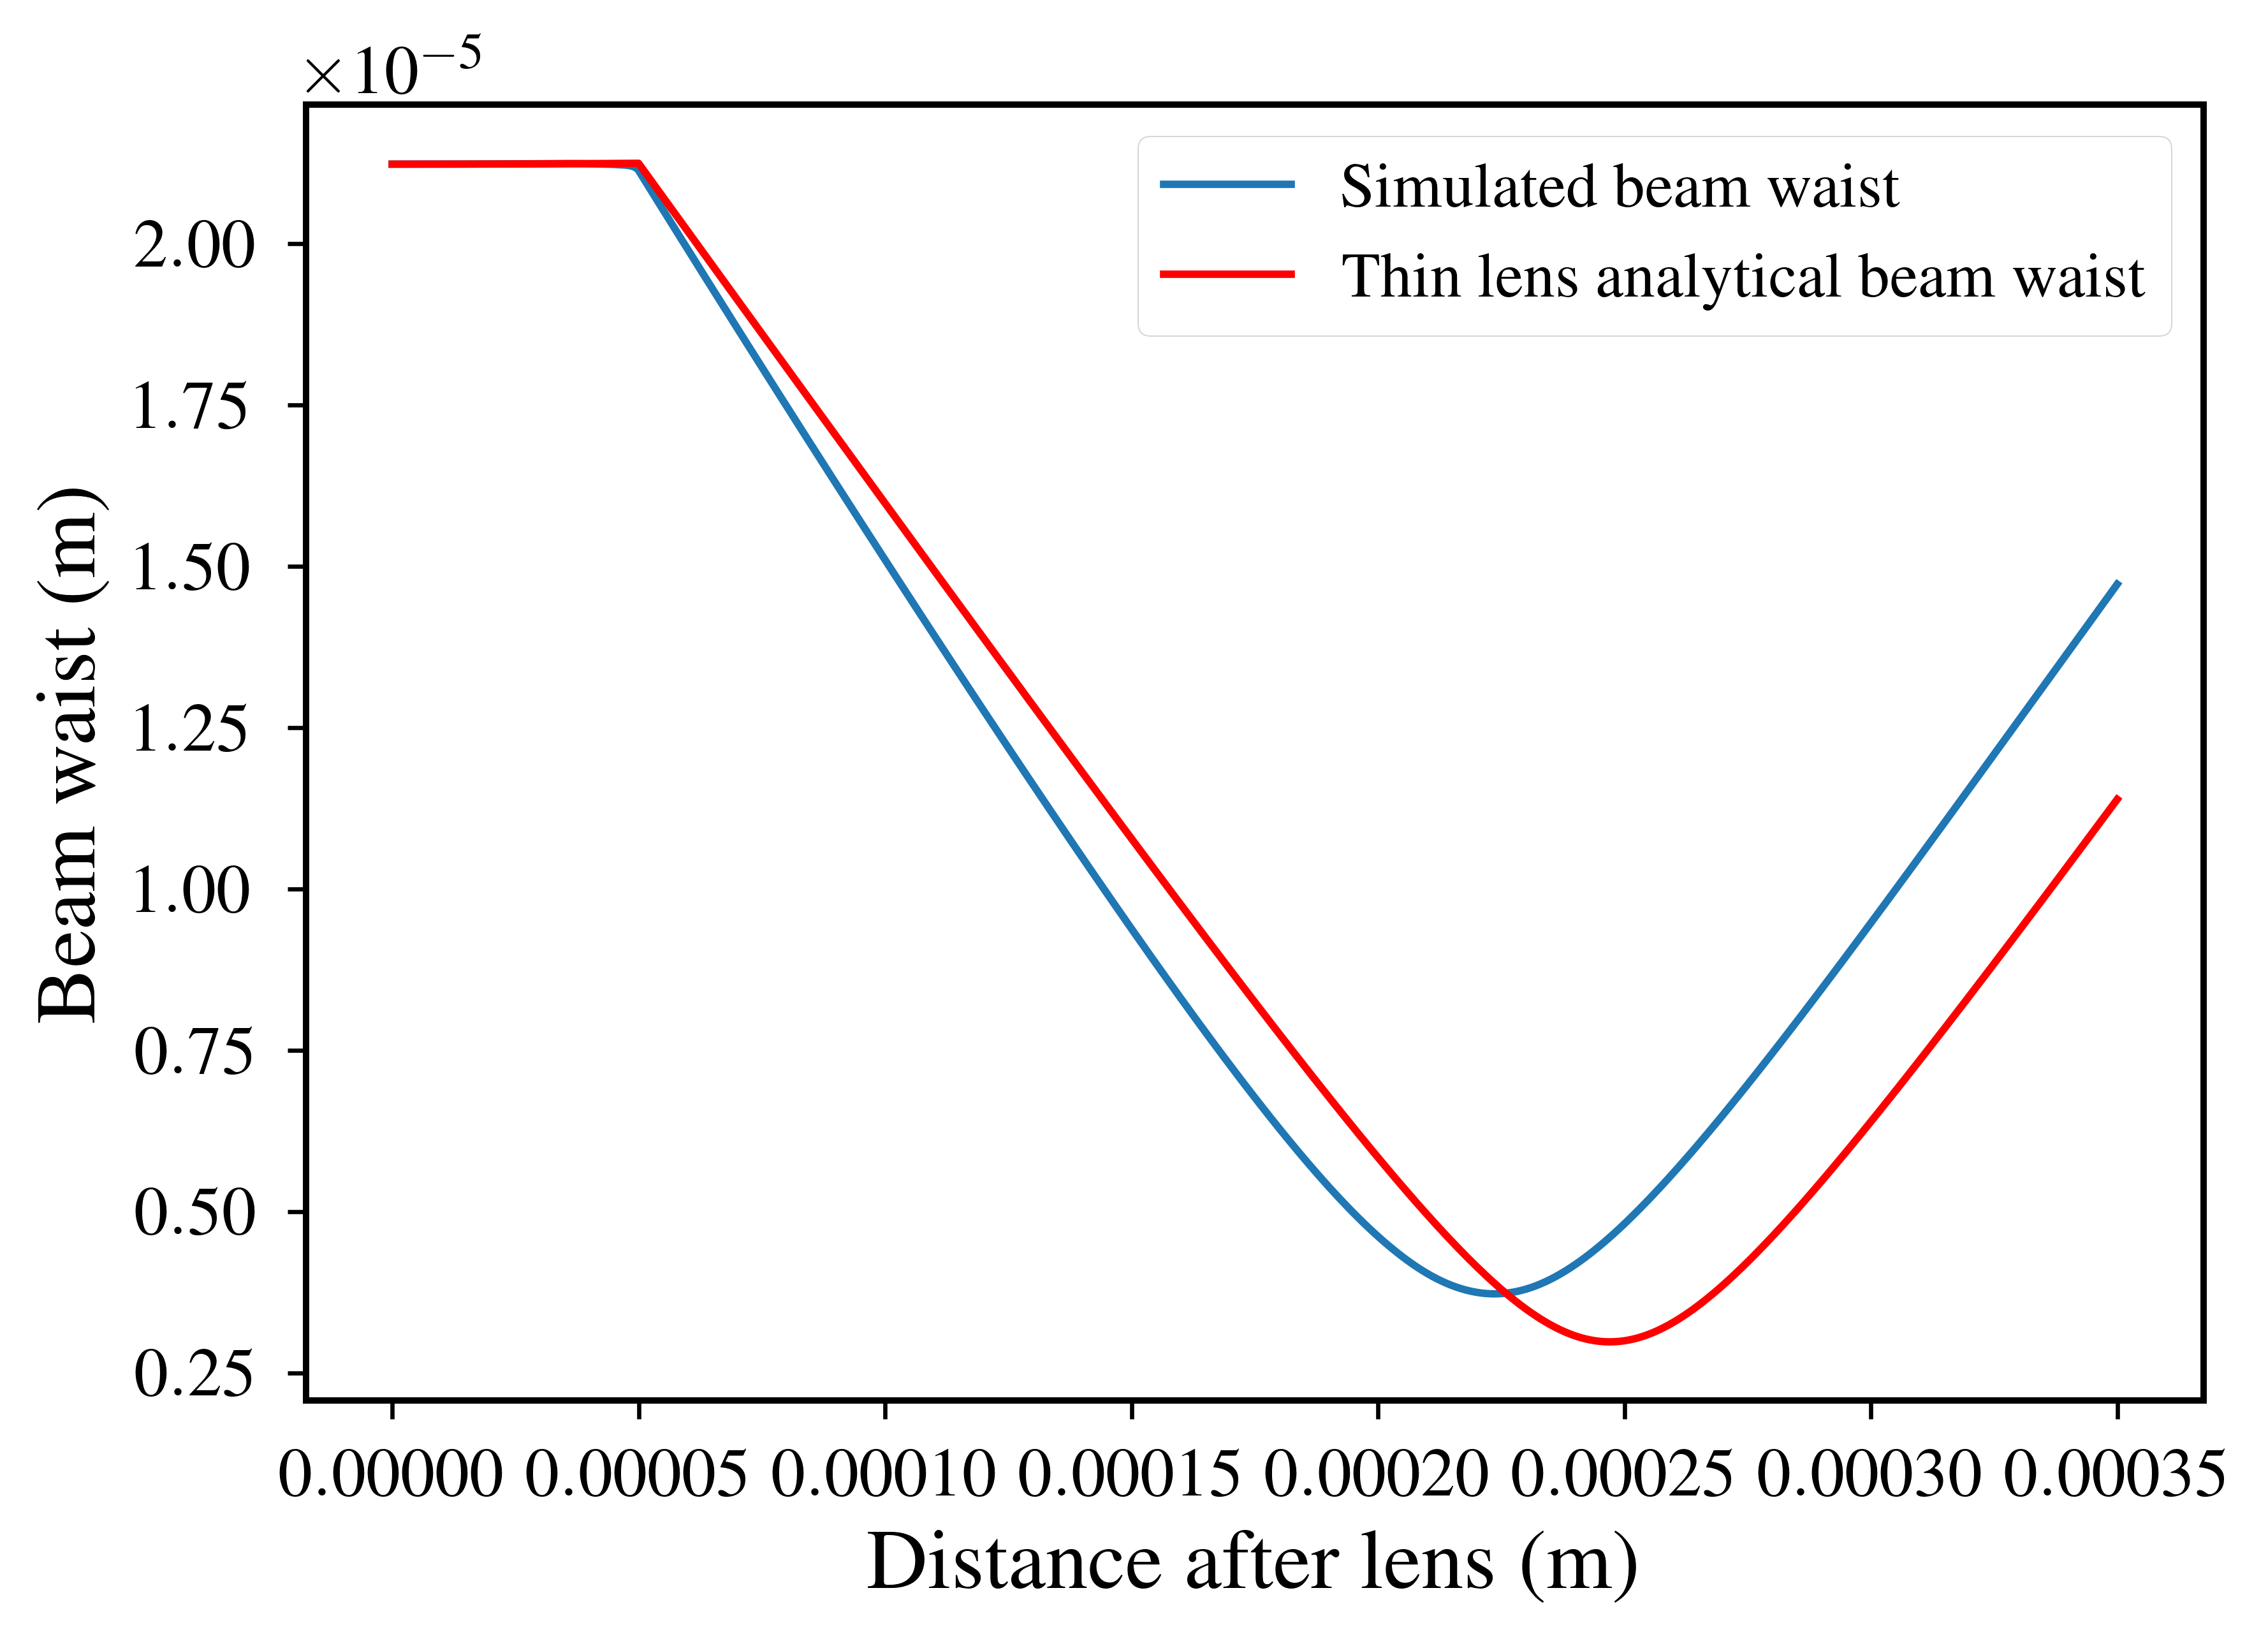

In [145]:
# from wave_optics_propagation.BeamProp_Script import prop, q1_inv_func

# plot beam waists
plt.plot(
    z_axis,
    beam_waists,
    "-",
    label="Simulated beam waist",
)

plt.plot(
    z_axis,
    analytical_beam_waists,
    "r-",
    label="Thin lens analytical beam waist",
)

# plt.plot(
#     distance_axis,
#     classical_numerics_beam_waists,
#     "g-",
#     label="Classical numerics beam waist",
# )


# plt.axvline(
#     x=ideal_focal_point,
#     color="black",
#     linestyle="--",
#     label="Ideal focal point",
# )
# plt.axhline(
#     y=beam_waist_after_lens,
#     color="gray",
#     linestyle="--",
#     label="Initial beam waist",
# )

plt.xlabel("Distance after lens (m)")
plt.ylabel("Beam waist (m)")
plt.legend()
plt.show()

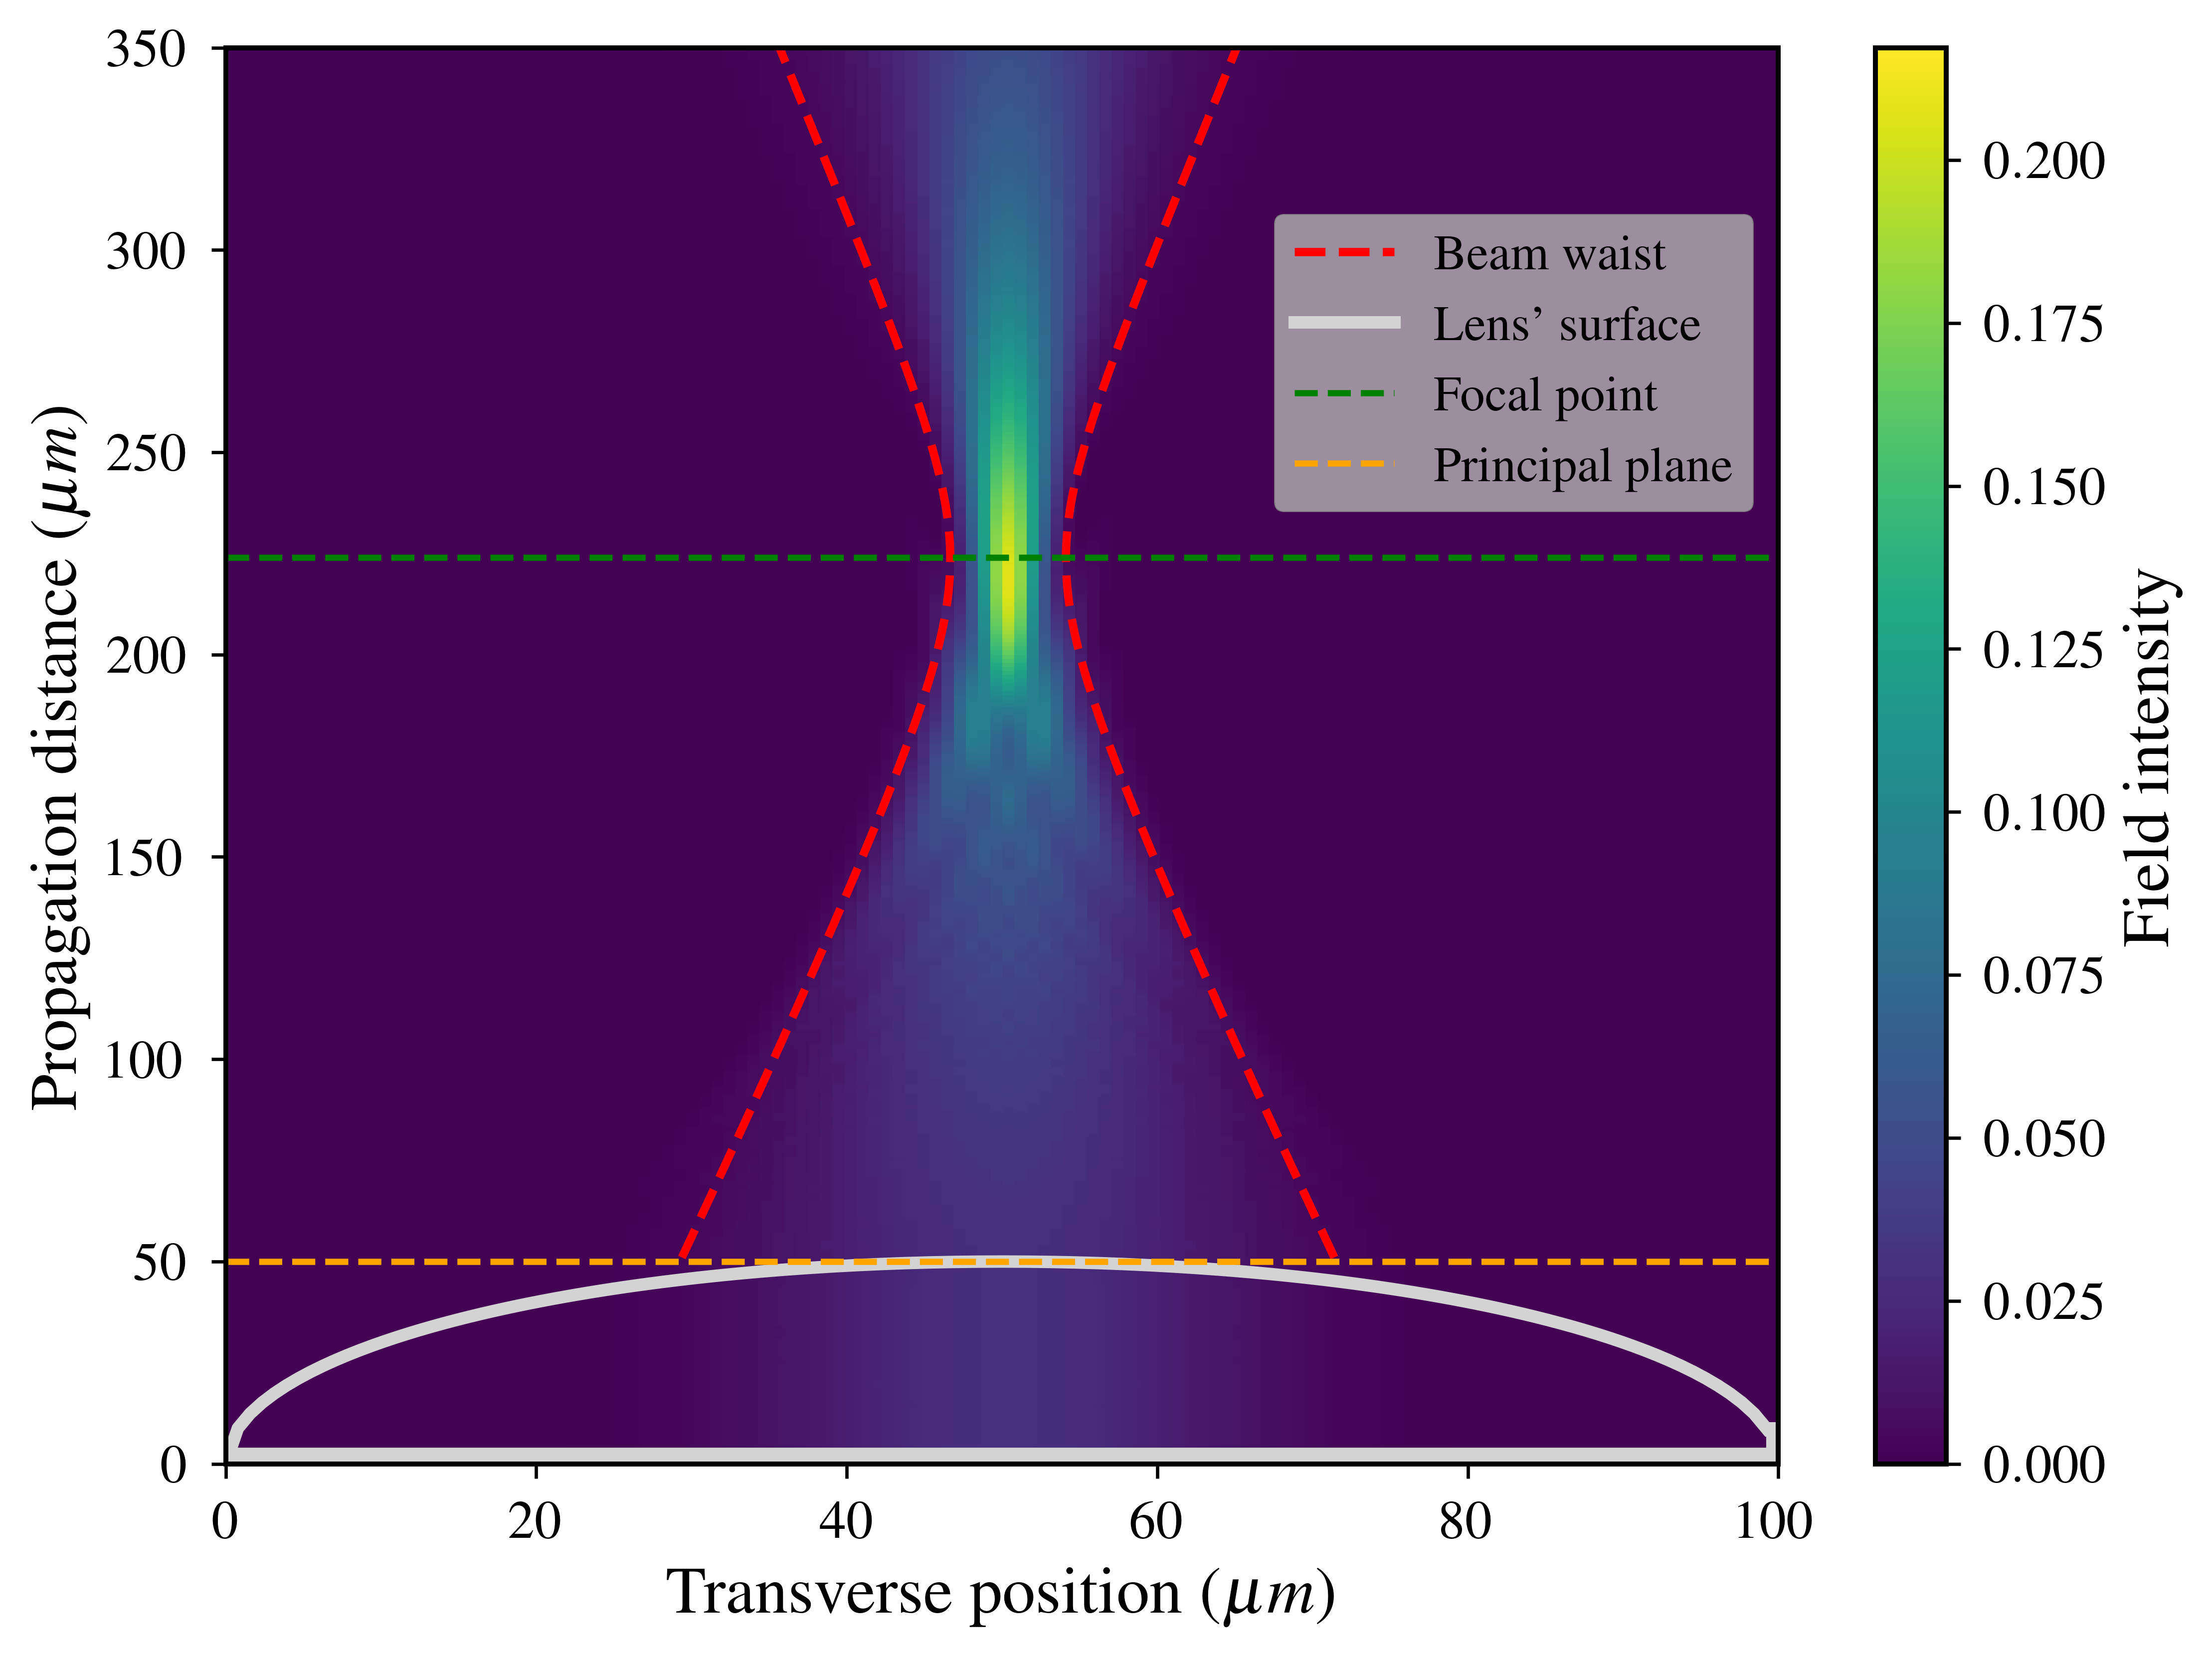

In [146]:
# fig, ax_color_plot = plt.subplots(1, 1, figsize=(1.3 * 6.4, 1.3 * 4.8))
fig, ax_color_plot = plt.subplots(1, 1, figsize=(1.2 * 6.4, 1.2 * 4.8))


vmin = 0
vmax = (
    np.max(
        [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None]
    )
    + 0.01
)

im1 = ax_color_plot.imshow(
    [np.abs(state) ** 2 for state in lens_statevectors if state is not None],
    extent=(0.0, params.transverse_length, 0.0, params.lens_thickness),
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)

im2 = ax_color_plot.imshow(
    [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None],
    extent=(
        0.0,
        params.transverse_length,
        params.lens_thickness,
        params.lens_thickness + params.propagation_after_lens,
    ),
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)
ax_color_plot.set_ylim(0, params.lens_thickness + params.propagation_after_lens)
ax_color_plot.set_xlim(0.0, params.transverse_length)

middle_point = params.transverse_length / 2 + params.delta_x / 2
ax_color_plot.plot(
    (middle_point + np.array(beam_waists))[params.lens_slices :],
    z_axis[params.lens_slices :],
    "r--",
    lw=2,
    label="Beam waist",
)

ax_color_plot.plot(
    (middle_point - np.array(beam_waists))[params.lens_slices :],
    z_axis[params.lens_slices :],
    "r--",
    lw=2,
)

if params.lens_reverse_order:
    y = (
        params.lens_thickness
        - (params.x_axis.axis_values - params.transverse_length / 2) ** 2
        / (2 * params.radius_of_curvature)
        if params.fresnel_approximation is True
        else params.lens_thickness
        + np.sqrt(
            params.radius_of_curvature**2
            - (params.lens_radius - params.x_axis.axis_values) ** 2
        )
        - params.radius_of_curvature
    )
    ax_color_plot.plot(
        params.x_axis.axis_values,
        y,
        color="lightgray",
        lw=3,
        ls="-",
        label="Lens' surface",
    )
    ax_color_plot.axhline(z_axis[0], color="lightgray", lw=8, ls="-")
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[0],
            params.x_axis.axis_values[0],
        ],
        [0, y[0]],
        color="lightgray",
        lw=6,
        ls="-",
    )
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[-1] + params.delta_x / 2,
            params.x_axis.axis_values[-1] + params.delta_x / 2,
        ],
        [0, y[-1]],
        color="lightgray",
        lw=3,
        ls="-",
    )
else:
    y = (
        (params.x_axis.axis_values - params.transverse_length / 2) ** 2
        / (2 * params.radius_of_curvature)
        if params.fresnel_approximation is True
        else params.radius_of_curvature
        - np.sqrt(
            params.radius_of_curvature**2
            - (params.x_axis.axis_values - params.transverse_length / 2) ** 2
        )
    )
    ax_color_plot.plot(
        params.x_axis.axis_values,
        y,
        color="lightgray",
        lw=3,
        ls="-",
        label="Lens surface",
    )
    ax_color_plot.axhline(
        params.lens_thickness,
        color="lightgray",
        lw=3,
        ls="-",
    )
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[0],
            params.x_axis.axis_values[0],
        ],
        [
            params.lens_thickness
            - 2 * params.propagation_after_lens / params.num_of_steps_after_lens,
            y[0] + 2 * params.propagation_after_lens / params.num_of_steps_after_lens,
        ],
        color="lightgray",
        lw=6,
        ls="-",
    )
    ax_color_plot.plot(
        [
            params.x_axis.axis_values[-1] + params.delta_x / 2,
            params.x_axis.axis_values[-1] + params.delta_x / 2,
        ],
        [params.lens_thickness, y[-1]],
        color="lightgray",
        lw=3,
        ls="-",
    )


ax_color_plot.set_xlabel(r"Transverse position ($\mu m$)")
ax_color_plot.set_ylabel(r"Propagation distance ($\mu m$)")

focal_point_index = np.argmin(beam_waists)
focal_point = z_axis[focal_point_index]

ax_color_plot.axhline(focal_point, color="green", lw=1.5, ls="--", label="Focal point")

ax_color_plot.axhline(
    principal_plane_position, color="orange", lw=1.5, ls="--", label="Principal plane"
)

cbar = fig.colorbar(im1, ax=ax_color_plot, label="Field intensity")

ax_color_plot.legend(
    loc="upper right",
    bbox_to_anchor=(1, 0.9),
    facecolor="0.7",  # darker gray background
    edgecolor="0.5",  # even darker border
)

ax_color_plot.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x * 1e6:g}")
)
ax_color_plot.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x * 1e6:g}")
)

fig.tight_layout()
fig.savefig(PATH_TO_RESULTS_FOLDER + "wave_propagation.pdf")

file_name = f"wave_propagation-{'r' if params.lens_reverse_order else 'nr'}-{'f' if params.fresnel_approximation else 'nf'}.pdf"
fig.savefig(".output/" + file_name)

In [147]:
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# fig, (ax_color_plot, ax_field) = plt.subplots(1, 2, figsize=(2 * 6.4, 1 * 4.8))

# vmin = 0
# vmax = (
#     np.max(
#         [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None]
#     )
#     + 0.01
# )

# im1 = ax_color_plot.imshow(
#     [np.abs(state) ** 2 for state in lens_statevectors if state is not None],
#     extent=(0.0, params.transverse_length, 0.0, params.lens_thickness),
#     aspect="auto",
#     vmin=vmin,
#     vmax=vmax,
#     origin="lower",
# )

# im2 = ax_color_plot.imshow(
#     [np.abs(state) ** 2 for state in after_lens_statevectors if state is not None],
#     extent=(
#         0.0,
#         params.transverse_length,
#         params.lens_thickness,
#         params.lens_thickness + params.propagation_after_lens,
#     ),
#     aspect="auto",
#     vmin=vmin,
#     vmax=vmax,
#     origin="lower",
# )
# ax_color_plot.set_ylim(0, params.lens_thickness + params.propagation_after_lens)
# ax_color_plot.set_xlim(0.0, params.transverse_length)

# middle_point = params.transverse_length / 2 + params.delta_x / 2
# ax_color_plot.plot(
#     (middle_point + np.array(beam_waists))[params.lens_slices :],
#     z_axis[params.lens_slices :],
#     "r--",
#     label="Beam waist",
# )

# ax_color_plot.plot(
#     (middle_point - np.array(beam_waists))[params.lens_slices :],
#     z_axis[params.lens_slices :],
#     "r--",
# )

# if params.lens_reverse_order:
#     y = (
#         params.lens_thickness
#         - (params.x_axis.axis_values - params.transverse_length / 2) ** 2
#         / (2 * params.radius_of_curvature)
#         if params.fresnel_approximation is True
#         else params.lens_thickness
#         + np.sqrt(
#             params.radius_of_curvature**2
#             - (params.lens_radius - params.x_axis.axis_values) ** 2
#         )
#         - params.radius_of_curvature
#     )
#     ax_color_plot.plot(
#         params.x_axis.axis_values, y, color="black", lw=3, ls="-", label="Lens surface"
#     )
#     ax_color_plot.axhline(z_axis[0], color="black", lw=8, ls="-")
#     ax_color_plot.plot(
#         [
#             params.x_axis.axis_values[0],
#             params.x_axis.axis_values[0],
#         ],
#         [0, y[0]],
#         color="black",
#         lw=6,
#         ls="-",
#     )
#     ax_color_plot.plot(
#         [
#             params.x_axis.axis_values[-1] + params.delta_x / 2,
#             params.x_axis.axis_values[-1] + params.delta_x / 2,
#         ],
#         [0, y[-1]],
#         color="black",
#         lw=3,
#         ls="-",
#     )
# else:
#     y = (
#         (params.x_axis.axis_values - params.transverse_length / 2) ** 2
#         / (2 * params.radius_of_curvature)
#         if params.fresnel_approximation is True
#         else np.sqrt(
#             params.radius_of_curvature**2
#             - (params.x_axis.axis_values - params.transverse_length / 2) ** 2
#         )
#         - params.radius_of_curvature
#     )
#     ax_color_plot.plot(
#         params.x_axis.axis_values, y, color="black", lw=3, ls="-", label="Lens surface"
#     )
#     ax_color_plot.axhline(params.lens_thickness, color="black", lw=3, ls="-")
#     ax_color_plot.plot(
#         [
#             params.x_axis.axis_values[0],
#             params.x_axis.axis_values[0],
#         ],
#         [params.lens_thickness, y[0]],
#         color="black",
#         lw=6,
#         ls="-",
#     )
#     ax_color_plot.plot(
#         [
#             params.x_axis.axis_values[-1] + params.delta_x / 2,
#             params.x_axis.axis_values[-1] + params.delta_x / 2,
#         ],
#         [params.lens_thickness, y[-1]],
#         color="black",
#         lw=3,
#         ls="-",
#     )


# ax_color_plot.set_xlabel(r"Transverse position ($\mu m$)")
# ax_color_plot.set_ylabel(r"Propagation distance ($\mu m$)")


# focal_point_index = np.argmin(beam_waists)
# focal_point = z_axis[focal_point_index]
# focal_statevector = full_sim_statevectors[focal_point_index]

# ax_field.plot(
#     params.x_axis.axis_values,
#     np.abs(focal_statevector) ** 2,
#     label="Simulated intensity at focal point",
# )
# ax_field.yaxis.tick_right()
# ax_field.yaxis.set_label_position("right")

# ax_field.set_xlabel(r"Transverse position ($\mu m$)")
# ax_field.set_ylabel("Field intensity")

# ax_color_plot.axhline(focal_point, color="green", lw=1, ls="--", label="Focal point")

# from matplotlib.patches import ConnectionPatch

# zoom_xlim = (0, params.transverse_length)
# zoom_ylim = (focal_point, focal_point)


# con1 = ConnectionPatch(
#     xyA=(params.transverse_length, focal_point),
#     axesA=ax_color_plot,
#     coordsA="data",
#     xyB=(0, 1),
#     axesB=ax_field,
#     coordsB="axes fraction",
#     color="black",
# )

# con2 = ConnectionPatch(
#     xyA=(params.transverse_length, focal_point),
#     axesA=ax_color_plot,
#     coordsA="data",
#     xyB=(0, 0),
#     axesB=ax_field,
#     coordsB="axes fraction",
#     color="black",
# )


# ax_color_plot.axhline(
#     principal_plane_position, color="gray", lw=1, ls="--", label="Principal plane"
# )

# fig.add_artist(con1)
# fig.add_artist(con2)

# cbar = fig.colorbar(
#     im1, ax=ax_color_plot, label="Field intensity", pad=0.2, location="left"
# )
# # cbar.ax.set_position((0, 0, 0, 0))

# fig.tight_layout()
# # fig.colorbar(img, ax=ax, label="Field intensity")
# fig.savefig(PATH_TO_RESULTS_FOLDER + "wave_propagation.pdf")
# fig.savefig(".output/wave_propagation.pdf")

In [148]:
focal_point

np.float64(0.00022400000000000002)

In [149]:
params.radius_of_curvature

5e-05